In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in os.listdir('/kaggle/input/competitions/plant-leaves-super-resolution-challenge/'):
#         print("/kaggle/input/competitions/plant-leaves-super-resolution-challenge/" + filename)

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import numpy as np
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# IMPORTING FILES

In [3]:
import numpy as np
import pandas as pd
import os
for filename in os.listdir('/kaggle/input/competitions/plant-leaves-super-resolution-challenge/'):
    print("/kaggle/input/competitions/plant-leaves-super-resolution-challenge/" + filename)

/kaggle/input/competitions/plant-leaves-super-resolution-challenge/sample_submission.csv
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/vgg19_weights.pth
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution


In [4]:
path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution/"
print(len(os.listdir(path)))

1642


In [5]:
lr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/"
hr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution/"

lr_files = sorted(os.listdir(lr_path))
hr_files = sorted(os.listdir(hr_path))

print(lr_files[0])
print(hr_files[0])

agrivision_train_0000.png
agrivision_train_0000.png


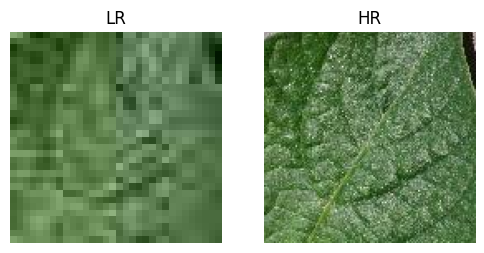

In [6]:
import cv2
import matplotlib.pyplot as plt

lr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/"
hr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution/"

img_name = "agrivision_train_0000.png"

lr = cv2.imread(lr_path + img_name)
hr = cv2.imread(hr_path + img_name)

# convert BGR -> RGB
lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("LR")
plt.imshow(lr)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("HR")
plt.imshow(hr)
plt.axis("off")

plt.show()

In [7]:
print("LR shape:", lr.shape)
print("HR shape:", hr.shape)

LR shape: (32, 32, 3)
HR shape: (128, 128, 3)


In [8]:
lr = lr / 255.0
hr = hr / 255.0

print(lr.min(), lr.max())
print(hr.min(), hr.max())

0.0 0.7098039215686275
0.0 1.0


In [9]:
lr = np.transpose(lr, (2, 0, 1))
hr = np.transpose(hr, (2, 0, 1))

print(lr.shape)
print(hr.shape)

(3, 32, 32)
(3, 128, 128)


In [10]:
import torch

lr = torch.tensor(lr, dtype=torch.float32)
hr = torch.tensor(hr, dtype=torch.float32)

print(type(lr), lr.shape)
print(type(hr), hr.shape)

<class 'torch.Tensor'> torch.Size([3, 32, 32])
<class 'torch.Tensor'> torch.Size([3, 128, 128])


# PREPROCESSING (ALL)

In [11]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class SRDataset(Dataset):
    def __init__(self, lr_path, hr_path):
        self.lr_path = lr_path
        self.hr_path = hr_path
        self.files = sorted(os.listdir(lr_path))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]

        # load
        lr = cv2.imread(self.lr_path + img_name)
        hr = cv2.imread(self.hr_path + img_name)

        # BGR -> RGB
        lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

        # normalize
        lr = lr / 255.0
        hr = hr / 255.0

        # HWC -> CHW
        lr = np.transpose(lr, (2, 0, 1))
        hr = np.transpose(hr, (2, 0, 1))

        # to tensor
        lr = torch.tensor(lr, dtype=torch.float32)
        hr = torch.tensor(hr, dtype=torch.float32)

        return lr, hr

In [12]:
lr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/"
hr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution/"

dataset = SRDataset(lr_path, hr_path)
print(len(dataset))

from torch.utils.data import DataLoader, random_split

# split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# quick checking
lr, hr = next(iter(train_loader))
print(lr.shape)
print(hr.shape)

1642
torch.Size([32, 3, 32, 32])
torch.Size([32, 3, 128, 128])


# GENERATOR

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, channels=64, growth=32):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, growth, 3, 1, 1)
        self.conv2 = nn.Conv2d(channels + growth, growth, 3, 1, 1)
        self.conv3 = nn.Conv2d(channels + 2*growth, growth, 3, 1, 1)
        self.conv4 = nn.Conv2d(channels + 3*growth, growth, 3, 1, 1)
        self.conv5 = nn.Conv2d(channels + 4*growth, channels, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], dim=1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], dim=1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))

        return x + 0.2 * x5



# RRDB Block
class RRDB(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.db1 = DenseBlock(channels)
        self.db2 = DenseBlock(channels)
        self.db3 = DenseBlock(channels)

    def forward(self, x):
        out = self.db1(x)
        out = self.db2(out)
        out = self.db3(out)
        return x + 0.2 * out



# Generator 
class Generator(nn.Module):
    def __init__(self, num_blocks=16):
        super().__init__()

        # first conv
        self.conv_first = nn.Conv2d(3, 64, 3, 1, 1)

        # RRDB trunk
        self.body = nn.Sequential(*[RRDB(64) for _ in range(num_blocks)])
        self.conv_body = nn.Conv2d(64, 64, 3, 1, 1)

        # upsampling
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # final conv
        self.conv_last = nn.Conv2d(64, 3, 3, 1, 1)

    def forward(self, x):
        x_in = x

        fea = self.conv_first(x)
        trunk = self.conv_body(self.body(fea))
        fea = fea + trunk

        out = self.upsample(fea)
        out = self.conv_last(out)

        # global skip
        x_up = F.interpolate(x_in, scale_factor=4, mode='bilinear', align_corners=False)
        out = out + x_up

        return torch.clamp(out, 0, 1)

G = Generator()

In [14]:
lr, _ = next(iter(train_loader))

# VALIDATION

In [15]:
lr, _ = next(iter(val_loader))

In [16]:
def validate(G, val_loader, device='cuda'): 
    G.eval()
    total_mae = 0

    with torch.no_grad():
        for lr, hr in val_loader:
            lr = lr.to(device)
            hr = hr.to(device)

            # Test-Time Augmentation 
            # Original
            out = G(lr)
            
            # orizontal flip
            out += torch.flip(G(torch.flip(lr, dims=[3])), dims=[3])
            
            # Vertical flip
            out += torch.flip(G(torch.flip(lr, dims=[2])), dims=[2])
            
            # Rotate 90
            out += G(lr.rot90(1, [2,3])).rot90(3, [2,3])
            
            # Rotate 180 
            out += G(lr.rot90(2, [2,3])).rot90(2, [2,3])
            
            # Rotate 270
            out += G(lr.rot90(3, [2,3])).rot90(1, [2,3])
            
            # Transpose
            out += G(lr.transpose(2, 3)).transpose(2, 3)
            
            # Anti-Transpose 
            lr_anti = torch.flip(lr, dims=[2,3]).transpose(2,3)
            out += torch.flip(G(lr_anti).transpose(2,3), dims=[2,3])

            # Average of 8 predictions
            out = out / 8.0

            # Calculate MAE
            mae = torch.abs(out - hr).mean()
            total_mae += mae.item()

    G.train()
    return total_mae / len(val_loader)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
G = G.to(device)

cuda


# LOSS

In [18]:
import torch.nn as nn

l1_loss = nn.L1Loss()

In [19]:
import torchvision.models as models

vgg = models.vgg19()
vgg.load_state_dict(torch.load('/kaggle/input/competitions/plant-leaves-super-resolution-challenge/vgg19_weights.pth'))
vgg = vgg.features[:16].to(device).eval()

for p in vgg.parameters():
    p.requires_grad = False

In [20]:
import torch.optim as optim

optimizer = optim.Adam(G.parameters(), lr=1e-4)

In [21]:
num_epochs = 70

for epoch in range(num_epochs):
    total_loss = 0

    for lr, hr in train_loader:   
        lr = lr.to(device)
        hr = hr.to(device)

        out = G(lr)
        loss = l1_loss(out, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader)}")  

Epoch 1, Loss: 0.08206615667967569
Epoch 2, Loss: 0.07256824807042167
Epoch 3, Loss: 0.07113663408727873
Epoch 4, Loss: 0.07077371710467906
Epoch 5, Loss: 0.0714542826726323
Epoch 6, Loss: 0.07040675587597348
Epoch 7, Loss: 0.07177980474772908
Epoch 8, Loss: 0.06984728947281837
Epoch 9, Loss: 0.06992660995040621
Epoch 10, Loss: 0.07008119433053903
Epoch 11, Loss: 0.07091705696213813
Epoch 12, Loss: 0.07013526399220739
Epoch 13, Loss: 0.06983229695331483
Epoch 14, Loss: 0.0694308527523563
Epoch 15, Loss: 0.07058195273081462
Epoch 16, Loss: 0.07050512154542264
Epoch 17, Loss: 0.06918937180723463
Epoch 18, Loss: 0.0697471953573681
Epoch 19, Loss: 0.06954308954023179
Epoch 20, Loss: 0.0683698866605049
Epoch 21, Loss: 0.0699146967381239
Epoch 22, Loss: 0.06882086502654212
Epoch 23, Loss: 0.06846635912855466
Epoch 24, Loss: 0.06916166850853533
Epoch 25, Loss: 0.06867966614663601
Epoch 26, Loss: 0.07009720589433398
Epoch 27, Loss: 0.06888610958343461
Epoch 28, Loss: 0.07032882626212779
Epoch 

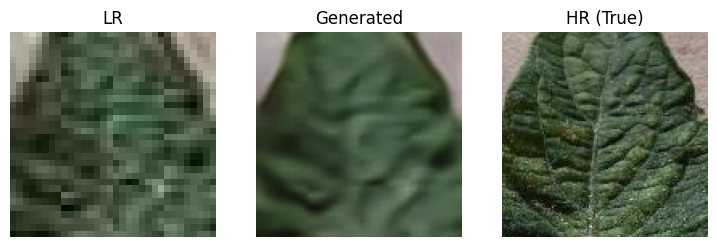

In [22]:
import matplotlib.pyplot as plt

lr, hr = next(iter(val_loader))
lr = lr.to(device)  
hr = hr.to(device)
out = G(lr)

lr_img = lr[0].permute(1,2,0).detach().cpu().numpy()
hr_img = hr[0].permute(1,2,0).detach().cpu().numpy()
out_img = out[0].permute(1,2,0).detach().cpu().numpy()

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Generated")
plt.imshow(out_img)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("HR (True)")
plt.imshow(hr_img)
plt.axis("off")

plt.show()

In [23]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.model = nn.Sequential(
            block(6, 64, 1),
            block(64, 64, 2),

            block(64, 128, 1),
            block(128, 128, 2),

            block(128, 256, 1),
            block(256, 256, 2),

            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(256, 1, 1)
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), -1)

D = Discriminator()

In [24]:
D = D.to(device)

In [25]:
import torch.nn.functional as F

lr_up = F.interpolate(lr, scale_factor=4)

real_input = torch.cat([lr_up, hr], dim=1)
fake_input = torch.cat([lr_up, out], dim=1)

In [26]:
real_pred = D(real_input)
fake_pred = D(fake_input)

print(real_pred.shape)

torch.Size([32, 1])


In [27]:
adv_loss = nn.BCEWithLogitsLoss()

real_labels = torch.ones_like(real_pred)
fake_labels = torch.zeros_like(fake_pred)

loss_real = adv_loss(real_pred, real_labels)
loss_fake = adv_loss(fake_pred, fake_labels)

loss_D = (loss_real + loss_fake) / 2

In [28]:
loss_GAN = adv_loss(fake_pred, real_labels)
loss_G = l1_loss(out, hr) + 0.001 * loss_GAN

In [29]:
print("D loss:", loss_D.item())
print("G loss:", loss_G.item())

D loss: 0.6936770677566528
G loss: 0.06918469071388245


# Training loop (Generator + Discriminator)

In [30]:
def charbonnier_loss(pred, target, eps=1e-3):
    return torch.mean(torch.sqrt((pred - target) ** 2 + eps**2))

In [31]:
def perceptual_loss(pred, target):
    return torch.mean((vgg(pred) - vgg(target))**2)

In [32]:
import os

num_epochs = 70

best_mae = float('inf')
second_best_mae = float('inf')
third_best_mae = float('inf')

for epoch in range(num_epochs):
    total_g_loss = 0

    # LR DECAY 
    if epoch == 25:
        for g in optimizer.param_groups:
            g['lr'] = 5e-5
        print("LR -> 5e-5")

    if epoch == 40:
        for g in optimizer.param_groups:
            g['lr'] = 1e-5
        print("LR -> 1e-5")

    for lr, hr in train_loader:
        lr = lr.to(device)
        hr = hr.to(device)


        out = G(lr)

        loss_G = charbonnier_loss(out, hr)

        optimizer.zero_grad()
        loss_G.backward()
        optimizer.step()

        total_g_loss += loss_G.item()

    print(f"Epoch {epoch+1}, G Loss: {total_g_loss / len(train_loader)}")

    # Validation
    val_mae = validate(G, val_loader)
    score = val_mae * 255
    print("Val MAE:", score)

    # Saving top 3 models 
    if score < best_mae:
        if os.path.exists("rrdb_best2.pth"):
            os.replace("rrdb_best2.pth", "rrdb_best3.pth")
        if os.path.exists("rrdb_best1.pth"):
            os.replace("rrdb_best1.pth", "rrdb_best2.pth")

        third_best_mae = second_best_mae
        second_best_mae = best_mae
        best_mae = score

        torch.save(G.state_dict(), "rrdb_best1.pth")
        print("Saved rrdb_best1")

    elif score < second_best_mae:
        if os.path.exists("rrdb_best2.pth"):
            os.replace("rrdb_best2.pth", "rrdb_best3.pth")

        third_best_mae = second_best_mae
        second_best_mae = score

        torch.save(G.state_dict(), "rrdb_best2.pth")
        print("Saved rrdb_best2")

    elif score < third_best_mae:
        third_best_mae = score
        torch.save(G.state_dict(), "rrdb_best3.pth")
        print("Saved rrdb_best3")

Epoch 1, G Loss: 0.06711129640184697
Val MAE: 16.88980066810142
Saved rrdb_best1
Epoch 2, G Loss: 0.0676264495012306
Val MAE: 16.868320593441073
Saved rrdb_best1
Epoch 3, G Loss: 0.06738627684258279
Val MAE: 16.850805260579694
Saved rrdb_best1
Epoch 4, G Loss: 0.0672765304999692
Val MAE: 16.836468198082663
Saved rrdb_best1
Epoch 5, G Loss: 0.06724769276167665
Val MAE: 16.820187798955224
Saved rrdb_best1
Epoch 6, G Loss: 0.06717871963268235
Val MAE: 16.855700347911228
Epoch 7, G Loss: 0.06775412052160218
Val MAE: 16.817297017709773
Saved rrdb_best1
Epoch 8, G Loss: 0.06751484973799615
Val MAE: 16.83401024815711
Saved rrdb_best3
Epoch 9, G Loss: 0.06814027506680716
Val MAE: 16.806866231967103
Saved rrdb_best1
Epoch 10, G Loss: 0.06700722216850236
Val MAE: 16.82666472413323
Epoch 11, G Loss: 0.06748037900598276
Val MAE: 16.806293585422363
Saved rrdb_best1
Epoch 12, G Loss: 0.06732584811037495
Val MAE: 16.81669820438732
Saved rrdb_best3
Epoch 13, G Loss: 0.06812032551637717
Val MAE: 16.800

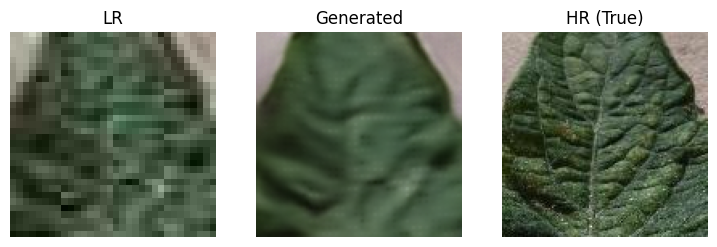

In [33]:
lr, hr = next(iter(val_loader))
lr = lr.to(device)
hr = hr.to(device)
out = G(lr)

lr_img = lr[0].permute(1,2,0).detach().cpu().numpy()
hr_img = hr[0].permute(1,2,0).detach().cpu().numpy()
out_img = out[0].permute(1,2,0).detach().cpu().numpy()


plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Generated")
plt.imshow(out_img)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("HR (True)")
plt.imshow(hr_img)
plt.axis("off")

plt.show()

In [34]:
class TestDataset(Dataset):
    def __init__(self, lr_path):
        self.lr_path = lr_path
        self.files = sorted(os.listdir(lr_path))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]

        lr = cv2.imread(self.lr_path + img_name)
        lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)

        lr = lr / 255.0
        lr = np.transpose(lr, (2,0,1))
        lr = torch.tensor(lr, dtype=torch.float32)

        return lr, img_name

In [35]:
test_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution/"
test_dataset = TestDataset(test_path)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [36]:
# Loading only the best model
G1 = Generator().to(device)
G1.load_state_dict(torch.load("rrdb_best1.pth", map_location=device))
G1.eval()

results = []

# Predict function
def predict(model, x):
    outs = []

    # original
    outs.append(model(x))

    # horizontal flip
    x_h = torch.flip(x, [3])
    outs.append(torch.flip(model(x_h), [3]))

    # vertical flip
    x_v = torch.flip(x, [2])
    outs.append(torch.flip(model(x_v), [2]))

    # both flips
    x_hv = torch.flip(x, [2,3])
    outs.append(torch.flip(model(x_hv), [2,3]))

    return sum(outs) / 4


# Test loop
for lr, name in test_loader:
    lr = lr.to(device)

    with torch.no_grad():
        out = predict(G1, lr)   # ONLY best1

    # convert to numpy
    out = out[0].permute(1,2,0).cpu().numpy()

    # rounding
    out = (out * 255.0).round().clip(0,255).astype(np.uint8)

    pixels = out.flatten()
    pixels_str = " ".join(map(str, pixels))

    results.append((name[0], pixels_str))

df = pd.DataFrame(results, columns=["Id", "Pixels"])
df.to_csv("submission.csv", index=False)

In [37]:
df = pd.DataFrame(results, columns=["Id", "Pixels"])
print(df.head())
df.to_csv("submission.csv", index=False)

                         Id                                             Pixels
0  agrivision_test_0000.png  156 155 156 158 153 155 157 152 153 156 151 15...
1  agrivision_test_0001.png  36 39 33 38 39 31 34 35 29 31 30 25 27 26 20 2...
2  agrivision_test_0002.png  116 126 110 122 127 113 126 129 116 130 132 12...
3  agrivision_test_0003.png  158 139 159 161 142 156 162 145 156 161 147 15...
4  agrivision_test_0004.png  123 104 113 124 104 109 123 107 110 123 108 10...


In [38]:
print(len(results[0][1].split()))

49152
